In [1]:
%matplotlib inline
import csv
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
import matplotlib
import scipy.interpolate as interpolate
import scipy.signal as signal
from matplotlib.patches import Rectangle
import scipy.stats as stats
import scipy.constants as const
import scipy.optimize as optimize
import scipy.interpolate as interpolate
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm  # For register_cmap
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.signal import find_peaks
from matplotlib.ticker import MaxNLocator, FixedLocator
from sklearn.linear_model import LinearRegression


**Settings** 

In [2]:
custom_blue = (0.0, 0.5, 0.9, 1.0)  # RGB for blue (#0099FF)

original_cmap = plt.get_cmap('RdGy_r')
n_colors = 256
colors = original_cmap(np.linspace(0, 1, n_colors))

colors[128:256, :] = np.linspace([0.5, 0.5, 0.5,0], custom_blue, 128)  # Fade from gray to blue
custom_cmap = ListedColormap(colors)

dark_red = np.array([0.7, 0.05, 0.15, 1.0], dtype=np.float64)

custom_green = (13/256, 179/256, 45/256, 1.0)
custom_blue = (34/255, 125/255, 251/255, 1)  # RGB for blue #227DFB
custom_red = (209/255, 37/255, 55/255, 1)  # RGB for red #D1254E

original_cmap = plt.get_cmap('RdGy_r')
n_colors = 256
colorsB = original_cmap(np.linspace(0, 1, n_colors))

colorsB[128:256, :] = np.linspace([0.5, 0.5, 0.5,0], custom_blue, 128)  # Fade from gray to blue
custom_cmap_blue = ListedColormap(colorsB)

original_cmap = plt.get_cmap('RdGy_r')
n_colors = 256
colorsR = original_cmap(np.linspace(0, 1, n_colors))

colorsR[128:256, :] = np.linspace([0.5, 0.5, 0.5,0], custom_red, 128)  # Fade from gray to blue
custom_cmap_red = ListedColormap(colorsR)

matplotlib.rcParams.update({
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'axes.labelsize': 18,
    'axes.titlesize': 18,
    'legend.fontsize': 18,
    # 'text.usetex': True
})

# Device D

## Weak Electron

Measurement (i)

In [35]:
name='C0062 4VBGm 1e Diamond MG'
filename='Z:/POBox/Jonas Gerber/05 - Measurements (Data)/EE01/Fritz2025 Cooldown C/2025/07/Data_0716/%s.hdf5'%name

data = h5py.File(filename, 'r')

# print([i for i in data])#Open just for reading "r"
# print([i for i in data['Data']['Channel names']])

V_SD=data['Data']['Data'][:,0,:] * 2
# print(V_PGv)
V_PG=data['Data']['Data'][:,1,:]
# print(Bz)
I_ACx=data['Data']['Data'][:,5,:]*1e-8
# Convert raw data to physical units
y_all = V_PG[:, 0:101]  # Gate 3 (V)
x_all = V_SD[:, 0:101]  # B⊥ (mT)
z_all = I_ACx[:, 0:101] * 1e12  # pA

# Compute grid centers
x_centers = y_all[0, :]  # Unique Gate 3 values (assuming constant along columns)
y_centers = x_all[:, 0]  # Unique B⊥ values (assuming constant along rows)

In [32]:
name='B0591 6VBG 1ediamond HQ'
filename='Z:/POBox/Jonas Gerber/05 - Measurements (Data)/EE01/Fritz2025/2025/05/Data_0514/%s.hdf5'%name

data = h5py.File(filename, 'r')

V_SD=data['Data']['Data'][:,0,:] * 2
# print(V_PGv)
V_PG=data['Data']['Data'][:,2,:]
# print(Bz)
I_ACx=data['Data']['Data'][:,4,:]*1e-8
# print(I_ACx)
# VSDAC=20e-6
# Convert raw data to physical units
y_all = V_PG 
x_all = V_SD      # mV
z_all = I_ACx * 1e12 # pA

x_centers = V_PG[0, :] 
y_centers = V_SD[:, 0]

In [37]:
name='B0451  6VBG 1h diamond lever arm'
filename='Z:/POBox/Jonas Gerber/05 - Measurements (Data)/EE01/Fritz2025/2025/04/Data_0427/%s.hdf5'%name

data = h5py.File(filename, 'r')

# print([i for i in data])#Open just for reading "r"
# print([i for i in data['Data']['Channel names']])
V_SD=data['Data']['Data'][:,0,:] * 2
# print(V_PGv)
V_PG=data['Data']['Data'][:,2,:]
# print(Bz)
I_ACx=data['Data']['Data'][:,4,:]*1e-8
# print(I_ACx)
# VSDAC=20e-6
# Convert raw data to physical units

y_all = V_PG   # V
x_all = V_SD      # mV
z_all = I_ACx * 1e12 # pA
# z_all = np.abs(z_all)  # so we also detect negative peaks

x_centers = V_PG[0, :] 
y_centers = V_SD[:, 0]

SOC Energy: 0.0621 ± 0.0023 meV


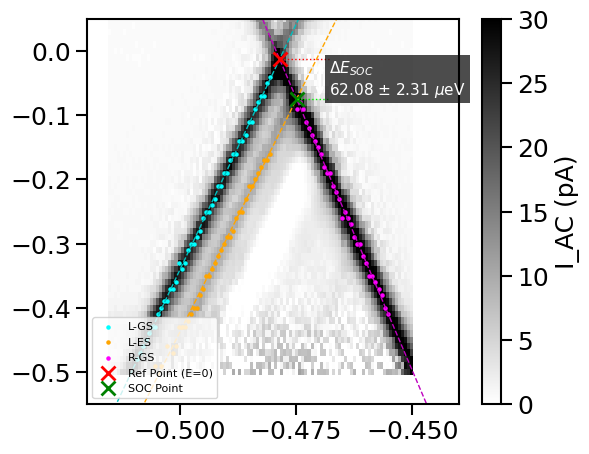

In [4]:
# --- CONFIGURATION ---
# Left Slope Region (Slope /)
roi_left_min = -0.512
roi_left_max = -0.480

# Right Slope Region (Slope \)
roi_right_min = -0.475
roi_right_max = -0.455

# Peak finding settings
min_peak_height = 3
min_peak_distance = 5
prominence_val = 2

# --- HELPER FUNCTION: FIND PEAKS IN RANGE ---
def find_lines_in_roi(gate_min, gate_max, look_for_es=False):
    gate_vals = x_centers
    indices = np.where((gate_vals >= gate_min) & (gate_vals <= gate_max))[0]
    
    gs_points = []
    es_points = []
    
    for col in indices:
        trace = z_all[:, col]
        peaks, properties = find_peaks(trace, height=min_peak_height, 
                                       distance=min_peak_distance, 
                                       prominence=prominence_val)
        
        if len(peaks) > 0:
            # 1. GS is the brightest peak
            gs_idx = peaks[np.argmax(properties['peak_heights'])]
            gs_E = y_centers[gs_idx]
            gs_points.append([gate_vals[col], gs_E])
            
            # 2. ES is below GS (only if requested)
            if look_for_es:
                # Find peaks with strictly lower energy
                candidates = [p for p in peaks if y_centers[p] < (gs_E - 0.005)]
                if candidates:
                    # Pick closest to GS (highest energy candidate)
                    es_idx = candidates[np.argmax([y_centers[p] for p in candidates])]
                    es_points.append([gate_vals[col], y_centers[es_idx]])

    return np.array(gs_points), np.array(es_points)

# --- 1. EXTRACT DATA ---
# Left Side: Need GS and ES
left_gs_data, left_es_data = find_lines_in_roi(roi_left_min, roi_left_max, look_for_es=True)
# Right Side: Need GS only
right_gs_data, _ = find_lines_in_roi(roi_right_min, roi_right_max, look_for_es=False)

# --- 2. FIT LINES WITH UNCERTAINTY ---
def fit_line_with_cov(data):
    if len(data) > 2:
        # polyfit returns: params [slope, intercept], covariance matrix
        params, cov = np.polyfit(data[:, 0], data[:, 1], 1, cov=True)
        return params, cov
    return None, None

# Fit all three lines
params_L_gs, cov_L_gs = fit_line_with_cov(left_gs_data)
params_L_es, cov_L_es = fit_line_with_cov(left_es_data)
params_R_gs, cov_R_gs = fit_line_with_cov(right_gs_data)

# --- 3. MONTE CARLO ERROR PROPAGATION ---
# We simulate N "versions" of the experiment based on the fit uncertainty
N_SIMULATIONS = 10000
soc_results = []

if params_L_gs is not None and params_L_es is not None and params_R_gs is not None:
    # Monte Carlo for Error Bar
    samples_L_gs = np.random.multivariate_normal(params_L_gs, cov_L_gs, N_SIMULATIONS)
    samples_L_es = np.random.multivariate_normal(params_L_es, cov_L_es, N_SIMULATIONS)
    samples_R_gs = np.random.multivariate_normal(params_R_gs, cov_R_gs, N_SIMULATIONS)

    m_Lgs, c_Lgs = samples_L_gs[:, 0], samples_L_gs[:, 1]
    m_Les, c_Les = samples_L_es[:, 0], samples_L_es[:, 1]
    m_Rgs, c_Rgs = samples_R_gs[:, 0], samples_R_gs[:, 1]

    # Calculate SOC for all simulations
    x_ref_sim = (c_Rgs - c_Lgs) / (m_Lgs - m_Rgs)
    y_ref_sim = m_Lgs * x_ref_sim + c_Lgs
    
    x_soc_sim = (c_Rgs - c_Les) / (m_Les - m_Rgs)
    y_soc_sim = m_Les * x_soc_sim + c_Les

    soc_dist = np.abs(y_ref_sim - y_soc_sim)
    final_soc_mean = np.mean(soc_dist)
    final_soc_std = np.std(soc_dist)
    
    # Calculate BEST FIT Intersection coordinates for Plotting (using mean params)
    m1, c1 = params_L_gs
    m2, c2 = params_L_es
    m3, c3 = params_R_gs
    
    # Point 1: Reference (Left GS + Right GS)
    x_ref_best = (c3 - c1) / (m1 - m3)
    y_ref_best = m1 * x_ref_best + c1
    
    # Point 2: SOC (Left ES + Right GS)
    x_soc_best = (c3 - c2) / (m2 - m3)
    y_soc_best = m2 * x_soc_best + c2
    
    print(f"SOC Energy: {final_soc_mean:.4f} ± {final_soc_std:.4f} meV")
else:
    final_soc_mean, final_soc_std = 0, 0
    raise ValueError("Fitting failed, cannot calculate SOC.")

# --- 4. PLOTTING ---
fig, ax = plt.subplots(figsize=(6, 5), dpi=100)
pcm = ax.pcolormesh(x_edges, y_edges, z_all, cmap='binary', vmin=0, vmax=30)
plt.colorbar(pcm, label='I_AC (pA)')

# Plot points
if len(left_gs_data) > 0: ax.scatter(left_gs_data[:,0], left_gs_data[:,1], c='cyan', s=5, label='L-GS')
if len(left_es_data) > 0: ax.scatter(left_es_data[:,0], left_es_data[:,1], c='orange', s=5, label='L-ES')
if len(right_gs_data) > 0: ax.scatter(right_gs_data[:,0], right_gs_data[:,1], c='magenta', s=5, label='R-GS')

# Plot Mean Lines
x_plot = np.linspace(-0.52, -0.44, 100)
if params_L_gs is not None: 
    ax.plot(x_plot, params_L_gs[0] * x_plot + params_L_gs[1], 'c--', lw=1)
    ax.plot(x_plot, params_L_es[0] * x_plot + params_L_es[1], 'orange', linestyle='--', lw=1)
    ax.plot(x_plot, params_R_gs[0] * x_plot + params_R_gs[1], 'm--', lw=1)

# --- VISUALIZE THE RESULT ---
if params_L_gs is not None:
    # 1. Mark the intersection points
    ax.plot(x_ref_best, y_ref_best, 'rx', markersize=10, markeredgewidth=2, label='Ref Point (E=0)')
    ax.plot(x_soc_best, y_soc_best, 'gx', markersize=10, markeredgewidth=2, label='SOC Point')

    # 2. Draw horizontal guides
    # Define a shared x-position for the vertical arrow (slightly to the right of the SOC point)
    arrow_x = x_soc_best + 0.005 
    
    ax.hlines(y_ref_best, x_ref_best, arrow_x + 0.002, colors='red', linestyles=':', linewidth=1)
    ax.hlines(y_soc_best, x_soc_best, arrow_x + 0.002, colors='lime', linestyles=':', linewidth=1)

    # 3. Draw the vertical arrow
    ax.annotate(
        '', xy=(arrow_x, y_ref_best), xytext=(arrow_x, y_soc_best),
        arrowprops=dict(arrowstyle='<->', color='white', lw=2)
    )
    
    # 4. Label the arrow
    mid_y = (y_ref_best + y_soc_best) / 2
    label_text = f"$\\Delta E_{{SOC}}$\n{final_soc_mean*1000:.2f} $\\pm$ {final_soc_std*1000:.2f} $\\mu$eV"
    
    ax.text(arrow_x + 0.002, mid_y, label_text, 
            color='white', fontsize=11, va='center', ha='left',
            bbox=dict(facecolor='black', alpha=0.7, edgecolor='none', pad=3))

ax.set_ylim(-0.55, 0.05)
ax.set_xlim(-0.52, -0.44)
ax.legend(loc='lower left', fontsize=8)
plt.show()

In [5]:
from matplotlib.widgets import Slider, Button
%matplotlib tk

In [19]:
# --- SETUP FIGURE ---
fig = plt.figure(figsize=(10, 9)) # Taller figure
# Reserve bottom 45% for sliders/buttons
plt.subplots_adjust(bottom=0.45) 

# Main plot area [left, bottom, width, height]
ax = fig.add_axes([0.15, 0.45, 0.70, 0.5]) 

# Initial Parameters
init_left_min, init_left_max = -0.512, -0.490
init_right_min, init_right_max = -0.470, -0.455
init_height = 3
init_dist = 5
init_prom = 2

# Plot Background
pcm = ax.pcolormesh(x_centers, y_centers, z_all if z_all.shape[0]==len(y_centers) else z_all.T, 
                    cmap='binary', vmin=0, vmax=30, shading='auto')
cbar_ax = fig.add_axes([0.88, 0.45, 0.02, 0.5])
fig.colorbar(pcm, cax=cbar_ax, label='I_AC (pA)')

# Plot Objects
scat_Lgs, = ax.plot([], [], 'o', color='cyan', markersize=3, label='L-GS', alpha=0.5)
scat_Les, = ax.plot([], [], 'o', color='orange', markersize=3, label='L-ES', alpha=0.5)
scat_Rgs, = ax.plot([], [], 'o', color='magenta', markersize=3, label='R-GS', alpha=0.5)

line_Lgs, = ax.plot([], [], 'c--', alpha=0.5)
line_Les, = ax.plot([], [], 'orange', linestyle='--', alpha=0.5)
line_Rgs, = ax.plot([], [], 'm--', alpha=0.5)

ref_marker, = ax.plot([], [], 'rx', ms=10, mew=2)
soc_marker, = ax.plot([], [], 'gx', ms=10, mew=2)
arrow_annotation = ax.annotate('', xy=(0,0), xytext=(0,0), arrowprops=dict(arrowstyle='<->', color='red'))
text_annotation = ax.text(0, 0, '', color='red', fontsize=12, fontweight='bold')

# Visual feedback for ROI
span_left = ax.axvspan(init_left_min, init_left_max, color='cyan', alpha=0.1)
span_right = ax.axvspan(init_right_min, init_right_max, color='magenta', alpha=0.1)

ax.set_ylim(-0.55, 0.05)
ax.set_xlim(-0.52, -0.44)
ax.set_xlabel("Gate Voltage (V)", labelpad=10)
ax.set_ylabel("Energy (meV)", labelpad=10)
ax.legend(loc='lower left', fontsize=8)

# --- WIDGET LAYOUT (Manual Coordinates) ---
# Format: [left, bottom, width, height]
# Spaced out vertically to prevent overlap

# ROW 1: Left ROI
ax_L_min = fig.add_axes([0.15, 0.32, 0.30, 0.03])
ax_L_max = fig.add_axes([0.60, 0.32, 0.30, 0.03])

# ROW 2: Right ROI
ax_R_min = fig.add_axes([0.15, 0.25, 0.30, 0.03])
ax_R_max = fig.add_axes([0.60, 0.25, 0.30, 0.03])

# ROW 3: Peak Parameters
ax_height = fig.add_axes([0.15, 0.18, 0.20, 0.03])
ax_dist   = fig.add_axes([0.45, 0.18, 0.20, 0.03])
ax_prom   = fig.add_axes([0.75, 0.18, 0.15, 0.03])

# ROW 4: Button
ax_button = fig.add_axes([0.40, 0.05, 0.20, 0.06])

# Create Widgets
s_L_min = Slider(ax_L_min, 'L Min', x_centers.min(), x_centers.max(), valinit=init_left_min)
s_L_max = Slider(ax_L_max, 'L Max', x_centers.min(), x_centers.max(), valinit=init_left_max)
s_R_min = Slider(ax_R_min, 'R Min', x_centers.min(), x_centers.max(), valinit=init_right_min)
s_R_max = Slider(ax_R_max, 'R Max', x_centers.min(), x_centers.max(), valinit=init_right_max)

s_height = Slider(ax_height, 'Height', 0, 20, valinit=init_height)
s_dist = Slider(ax_dist, 'Dist', 1, 20, valinit=init_dist, valstep=1)
s_prom = Slider(ax_prom, 'Prom', 0.1, 10, valinit=init_prom)

btn_mc = Button(ax_button, 'Run MC Error\nSimulation', color='lightgray', hovercolor='lightblue')

# --- SHARED STATE ---
# We store current fitted data here so the button can access it
current_data = {
    'Lgs': None, 'Les': None, 'Rgs': None,
    'p1': None, 'p2': None, 'p3': None
}

# --- UPDATE FUNCTION (Real-time) ---
def update(val):
    l_min, l_max = s_L_min.val, s_L_max.val
    r_min, r_max = s_R_min.val, s_R_max.val
    h, d, p = s_height.val, s_dist.val, s_prom.val
    
    # Update spans
    span_left.set_x(l_min); span_left.set_width(l_max - l_min)
    span_right.set_x(r_min); span_right.set_width(r_max - r_min)
    
    # Find points
    def find_pts(g_min, g_max, look_es):
        indices = np.where((x_centers >= g_min) & (x_centers <= g_max))[0]
        gs, es = [], []
        for col in indices:
            trace = z_all[:, col]
            peaks, props = find_peaks(trace, height=h, distance=d, prominence=p)
            if len(peaks) > 0:
                gs_idx = peaks[np.argmax(props['peak_heights'])]
                gs_E = y_centers[gs_idx]
                gs.append([x_centers[col], gs_E])
                if look_es:
                    cands = [k for k in peaks if y_centers[k] < (gs_E - 0.005)]
                    if cands:
                        es_idx = cands[np.argmax([y_centers[k] for k in cands])]
                        es.append([x_centers[col], y_centers[es_idx]])
        return np.array(gs), np.array(es)

    Lgs, Les = find_pts(l_min, l_max, True)
    Rgs, _ = find_pts(r_min, r_max, False)
    
    current_data['Lgs'], current_data['Les'], current_data['Rgs'] = Lgs, Les, Rgs
    
    # Update Scatters
    scat_Lgs.set_data(Lgs[:,0], Lgs[:,1]) if len(Lgs) else scat_Lgs.set_data([],[])
    scat_Les.set_data(Les[:,0], Les[:,1]) if len(Les) else scat_Les.set_data([],[])
    scat_Rgs.set_data(Rgs[:,0], Rgs[:,1]) if len(Rgs) else scat_Rgs.set_data([],[])
    
    # Fit
    def fit(data): return np.polyfit(data[:,0], data[:,1], 1) if len(data)>2 else None
    p1, p2, p3 = fit(Lgs), fit(Les), fit(Rgs)
    current_data['p1'], current_data['p2'], current_data['p3'] = p1, p2, p3
    
    x_plt = np.linspace(-0.52, -0.44, 100)
    
    # Update Lines
    if p1 is not None: line_Lgs.set_data(x_plt, p1[0]*x_plt + p1[1])
    else: line_Lgs.set_data([],[])
    if p2 is not None: line_Les.set_data(x_plt, p2[0]*x_plt + p2[1])
    else: line_Les.set_data([],[])
    if p3 is not None: line_Rgs.set_data(x_plt, p3[0]*x_plt + p3[1])
    else: line_Rgs.set_data([],[])
        
    # Calculate Instant SOC (No Error)
    if p1 is not None and p2 is not None and p3 is not None:
        x_ref = (p3[1] - p1[1]) / (p1[0] - p3[0])
        y_ref = p1[0] * x_ref + p1[1]
        x_soc = (p3[1] - p2[1]) / (p2[0] - p3[0])
        y_soc = p2[0] * x_soc + p2[1]
        soc_val = np.abs(y_ref - y_soc) * 1000
        
        ref_marker.set_data([x_ref], [y_ref])
        soc_marker.set_data([x_soc], [y_soc])
        arrow_annotation.set_visible(True)
        arrow_annotation.xy = (x_soc, y_ref)
        arrow_annotation.set_position((x_soc, y_soc))
        text_annotation.set_text(f"{soc_val:.1f} µeV")
        text_annotation.set_position((x_soc + 0.002, (y_ref+y_soc)/2))
        ax.set_title(f"SOC (Est): {soc_val:.2f} µeV (Click Button for Error)", fontsize=12)
    else:
        ref_marker.set_data([],[])
        soc_marker.set_data([],[])
        arrow_annotation.set_visible(False)
        text_annotation.set_text("")
        ax.set_title("Insufficient Data")

    fig.canvas.draw_idle()

# --- MONTE CARLO FUNCTION (Triggered by Button) ---
def run_mc(event):
    Lgs, Les, Rgs = current_data['Lgs'], current_data['Les'], current_data['Rgs']
    
    if len(Lgs) < 3 or len(Les) < 3 or len(Rgs) < 3:
        ax.set_title("Cannot run MC: Need more points (min 3 per line)")
        fig.canvas.draw_idle()
        return

    ax.set_title("Running Simulation...")
    fig.canvas.draw() # Force update
    
    # Fit with Covariance
    def get_cov(d): return np.polyfit(d[:,0], d[:,1], 1, cov=True)
    p1, cov1 = get_cov(Lgs)
    p2, cov2 = get_cov(Les)
    p3, cov3 = get_cov(Rgs)
    
    # Simulate
    N = 5000
    s1 = np.random.multivariate_normal(p1, cov1, N)
    s2 = np.random.multivariate_normal(p2, cov2, N)
    s3 = np.random.multivariate_normal(p3, cov3, N)
    
    # Vectorized Intersection Calc
    # Ref (1 & 3)
    x_ref = (s3[:,1] - s1[:,1]) / (s1[:,0] - s3[:,0])
    y_ref = s1[:,0] * x_ref + s1[:,1]
    
    # SOC (2 & 3)
    x_soc = (s3[:,1] - s2[:,1]) / (s2[:,0] - s3[:,0])
    y_soc = s2[:,0] * x_soc + s2[:,1]
    
    diffs = np.abs(y_ref - y_soc) * 1000 # uV
    mean_val = np.mean(diffs)
    std_val = np.std(diffs)
    
    ax.set_title(f"SOC: {mean_val:.2f} ± {std_val:.2f} µeV (N={N})", fontsize=14, color='green', fontweight='bold')
    print(f"MC Result: {mean_val:.4f} +/- {std_val:.4f} uV")
    fig.canvas.draw_idle()

# Connect Callbacks
s_L_min.on_changed(update)
s_L_max.on_changed(update)
s_R_min.on_changed(update)
s_R_max.on_changed(update)
s_height.on_changed(update)
s_dist.on_changed(update)
s_prom.on_changed(update)
btn_mc.on_clicked(run_mc)

# Initialize
update(None)
plt.show()

MC Result: 60.7008 +/- 2.2068 uV
MC Result: 60.7955 +/- 2.1989 uV


In [20]:
# --- 2. DYNAMIC RANGE CALCULATION ---
# We compute these ONCE so everything scales to your specific dataset
x_min, x_max = np.min(x_centers), np.max(x_centers)
y_min, y_max = np.min(y_centers), np.max(y_centers)
z_max_val = np.max(z_all)
x_range = x_max - x_min

# Smart Defaults for ROIs (First 25% and Last 25% of the plot)
init_left_min  = x_min + 0.05 * x_range
init_left_max  = x_min + 0.30 * x_range
init_right_min = x_max - 0.30 * x_range
init_right_max = x_max - 0.05 * x_range

# Smart Defaults for Peak Finding (scaled to signal strength)
init_height = 0.1 * z_max_val  # Default to 10% of max signal
init_dist   = 5                # 5 pixels is usually safe
init_prom   = 0.05 * z_max_val # 5% of max signal

# --- 3. SETUP FIGURE ---
fig = plt.figure(figsize=(10, 9))
plt.subplots_adjust(bottom=0.45) # Reserve bottom 45% for controls

# Main Axes [left, bottom, width, height]
# We use 0.70 width to ensure the right label fits
ax = fig.add_axes([0.15, 0.45, 0.70, 0.5]) 

# Plot Background
pcm = ax.pcolormesh(x_centers, y_centers, z_all if z_all.shape[0]==len(y_centers) else z_all.T, 
                    cmap='binary', shading='auto')

# Colorbar (Positioned safely to avoiding cutting text)
cbar_ax = fig.add_axes([0.88, 0.45, 0.02, 0.5])
fig.colorbar(pcm, cax=cbar_ax, label='Signal Amplitude')

# --- PLOT OBJECTS (Empty initially) ---
scat_Lgs, = ax.plot([], [], 'o', color='cyan', markersize=3, label='L-GS', alpha=0.5)
scat_Les, = ax.plot([], [], 'o', color='orange', markersize=3, label='L-ES', alpha=0.5)
scat_Rgs, = ax.plot([], [], 'o', color='magenta', markersize=3, label='R-GS', alpha=0.5)

line_Lgs, = ax.plot([], [], 'c--', alpha=0.5)
line_Les, = ax.plot([], [], 'orange', linestyle='--', alpha=0.5)
line_Rgs, = ax.plot([], [], 'm--', alpha=0.5)

ref_marker, = ax.plot([], [], 'rx', ms=10, mew=2)
soc_marker, = ax.plot([], [], 'gx', ms=10, mew=2)
arrow_annotation = ax.annotate('', xy=(0,0), xytext=(0,0), arrowprops=dict(arrowstyle='<->', color='red'))
text_annotation = ax.text(0, 0, '', color='red', fontsize=12, fontweight='bold')

# ROI Visual Feedback
span_left = ax.axvspan(init_left_min, init_left_max, color='cyan', alpha=0.1)
span_right = ax.axvspan(init_right_min, init_right_max, color='magenta', alpha=0.1)

# Set Axes Limits dynamically
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel("Gate Voltage", labelpad=10)
ax.set_ylabel("Energy / Bias", labelpad=10)
ax.legend(loc='lower left', fontsize=8)

# --- 4. WIDGET LAYOUT ---
# Row 1: Left ROI
ax_L_min = fig.add_axes([0.15, 0.32, 0.30, 0.03])
ax_L_max = fig.add_axes([0.60, 0.32, 0.30, 0.03])

# Row 2: Right ROI
ax_R_min = fig.add_axes([0.15, 0.25, 0.30, 0.03])
ax_R_max = fig.add_axes([0.60, 0.25, 0.30, 0.03])

# Row 3: Parameters
ax_height = fig.add_axes([0.15, 0.18, 0.20, 0.03])
ax_dist   = fig.add_axes([0.45, 0.18, 0.20, 0.03])
ax_prom   = fig.add_axes([0.75, 0.18, 0.15, 0.03])

# Row 4: Button
ax_button = fig.add_axes([0.40, 0.05, 0.20, 0.06])

# Create Sliders (Ranges are dynamic now)
s_L_min = Slider(ax_L_min, 'L Min', x_min, x_max, valinit=init_left_min)
s_L_max = Slider(ax_L_max, 'L Max', x_min, x_max, valinit=init_left_max)
s_R_min = Slider(ax_R_min, 'R Min', x_min, x_max, valinit=init_right_min)
s_R_max = Slider(ax_R_max, 'R Max', x_min, x_max, valinit=init_right_max)

# Max Height/Prominence sliders scale to 50% of max signal
s_height = Slider(ax_height, 'Height', 0, z_max_val * 0.5, valinit=init_height)
s_dist   = Slider(ax_dist, 'Dist (px)', 1, 50, valinit=init_dist, valstep=1)
s_prom   = Slider(ax_prom, 'Prom', 0, z_max_val * 0.5, valinit=init_prom)

btn_mc = Button(ax_button, 'Run MC Error\nSimulation', color='lightgray', hovercolor='lightblue')

# Shared State
current_data = {'Lgs': None, 'Les': None, 'Rgs': None}

# --- 5. LOGIC & CALLBACKS ---
def update(val):
    l_min, l_max = s_L_min.val, s_L_max.val
    r_min, r_max = s_R_min.val, s_R_max.val
    h, d, p = s_height.val, s_dist.val, s_prom.val
    
    # Update Spans
    span_left.set_x(l_min); span_left.set_width(l_max - l_min)
    span_right.set_x(r_min); span_right.set_width(r_max - r_min)
    
    # Find Points
    def find_pts(g_min, g_max, look_es):
        # Filter indices within range
        indices = np.where((x_centers >= g_min) & (x_centers <= g_max))[0]
        gs, es = [], []
        
        # Buffer to find ES below GS (0.5% of Y-range)
        y_buffer = (y_max - y_min) * 0.005
        
        for col in indices:
            trace = z_all[:, col]
            peaks, props = find_peaks(trace, height=h, distance=d, prominence=p)
            if len(peaks) > 0:
                gs_idx = peaks[np.argmax(props['peak_heights'])]
                gs_E = y_centers[gs_idx]
                gs.append([x_centers[col], gs_E])
                if look_es:
                    # Generic check: Look strictly below GS
                    cands = [k for k in peaks if y_centers[k] < (gs_E - y_buffer)]
                    if cands:
                        # Pick closest (highest energy candidate)
                        es_idx = cands[np.argmax([y_centers[k] for k in cands])]
                        es.append([x_centers[col], y_centers[es_idx]])
        return np.array(gs), np.array(es)

    Lgs, Les = find_pts(l_min, l_max, True)
    Rgs, _ = find_pts(r_min, r_max, False)
    
    current_data['Lgs'], current_data['Les'], current_data['Rgs'] = Lgs, Les, Rgs
    
    # Update Points
    scat_Lgs.set_data(Lgs[:,0], Lgs[:,1]) if len(Lgs) else scat_Lgs.set_data([],[])
    scat_Les.set_data(Les[:,0], Les[:,1]) if len(Les) else scat_Les.set_data([],[])
    scat_Rgs.set_data(Rgs[:,0], Rgs[:,1]) if len(Rgs) else scat_Rgs.set_data([],[])
    
    # Fit & Plot Lines
    def fit(data): return np.polyfit(data[:,0], data[:,1], 1) if len(data)>2 else None
    p1, p2, p3 = fit(Lgs), fit(Les), fit(Rgs)
    
    # Generate X-points for lines (spanning the full visible window)
    x_plt = np.linspace(x_min, x_max, 100)
    
    if p1 is not None: line_Lgs.set_data(x_plt, p1[0]*x_plt + p1[1])
    else: line_Lgs.set_data([],[])
    if p2 is not None: line_Les.set_data(x_plt, p2[0]*x_plt + p2[1])
    else: line_Les.set_data([],[])
    if p3 is not None: line_Rgs.set_data(x_plt, p3[0]*x_plt + p3[1])
    else: line_Rgs.set_data([],[])
        
    # Calculate SOC
    if p1 is not None and p2 is not None and p3 is not None:
        x_ref = (p3[1] - p1[1]) / (p1[0] - p3[0])
        y_ref = p1[0] * x_ref + p1[1]
        x_soc = (p3[1] - p2[1]) / (p2[0] - p3[0])
        y_soc = p2[0] * x_soc + p2[1]
        
        # Determine unit scale (assume if < 1 it's likely eV or meV, multiply by 1000 for display)
        # Or just stick to the user's unit * 1000 assuming it's meV -> uV
        soc_val = np.abs(y_ref - y_soc) * 1000 
        
        ref_marker.set_data([x_ref], [y_ref])
        soc_marker.set_data([x_soc], [y_soc])
        
        arrow_annotation.set_visible(True)
        arrow_annotation.xy = (x_soc, y_ref)
        arrow_annotation.set_position((x_soc, y_soc))
        
        text_annotation.set_text(f"{soc_val:.1f} (scaled)")
        text_annotation.set_position((x_soc + (x_range*0.02), (y_ref+y_soc)/2))
        ax.set_title(f"Splitting: {soc_val:.2f} (x1000 units)", fontsize=12)
    else:
        ref_marker.set_data([],[])
        soc_marker.set_data([],[])
        arrow_annotation.set_visible(False)
        text_annotation.set_text("")
        ax.set_title("Insufficient Data for Fit")

    fig.canvas.draw_idle()

def run_mc(event):
    Lgs, Les, Rgs = current_data['Lgs'], current_data['Les'], current_data['Rgs']
    if len(Lgs) < 3 or len(Les) < 3 or len(Rgs) < 3:
        ax.set_title("Cannot run MC: Need >3 points per line")
        fig.canvas.draw_idle(); return

    ax.set_title("Running Simulation...")
    fig.canvas.draw()
    
    def get_cov(d): return np.polyfit(d[:,0], d[:,1], 1, cov=True)
    p1, cov1 = get_cov(Lgs)
    p2, cov2 = get_cov(Les)
    p3, cov3 = get_cov(Rgs)
    
    N = 5000
    s1 = np.random.multivariate_normal(p1, cov1, N)
    s2 = np.random.multivariate_normal(p2, cov2, N)
    s3 = np.random.multivariate_normal(p3, cov3, N)
    
    x_ref = (s3[:,1] - s1[:,1]) / (s1[:,0] - s3[:,0])
    y_ref = s1[:,0] * x_ref + s1[:,1]
    
    x_soc = (s3[:,1] - s2[:,1]) / (s2[:,0] - s3[:,0])
    y_soc = s2[:,0] * x_soc + s2[:,1]
    
    diffs = np.abs(y_ref - y_soc) * 1000
    mean, std = np.mean(diffs), np.std(diffs)
    
    ax.set_title(f"Result: {mean:.2f} ± {std:.2f} (x1000 units)", fontsize=14, color='green', fontweight='bold')
    print(f"MC Result: {mean:.4f} +/- {std:.4f}")
    fig.canvas.draw_idle()

# Connect
s_L_min.on_changed(update); s_L_max.on_changed(update)
s_R_min.on_changed(update); s_R_max.on_changed(update)
s_height.on_changed(update); s_dist.on_changed(update); s_prom.on_changed(update)
btn_mc.on_clicked(run_mc)

update(None)
plt.show()

MC Result: 62.2318 +/- 2.8728


In [38]:
# --- 2. DYNAMIC INITIALIZATION ---
# Calculate data bounds to set slider ranges
d_x_min, d_x_max = np.min(x_centers), np.max(x_centers)
d_y_min, d_y_max = np.min(y_centers), np.max(y_centers)
d_z_max = np.max(z_all)
x_span = d_x_max - d_x_min

# Initial guesses for ROI (25% and 75% positions)
init_L_min = d_x_min + 0.05 * x_span
init_L_max = d_x_min + 0.30 * x_span
init_R_min = d_x_max - 0.30 * x_span
init_R_max = d_x_max - 0.05 * x_span

# Initial Peak Parameters
init_h = 0.1 * d_z_max
init_d = 5
init_p = 0.05 * d_z_max

# --- 3. FIGURE SETUP ---
fig = plt.figure(figsize=(11, 7))
# Reserve bottom 40% for Analysis controls
# Reserve top 15% for Zoom controls
plt.subplots_adjust(bottom=0.40, top=0.85) 

# Main Plot Axes
ax = fig.add_axes([0.15, 0.35, 0.65, 0.55]) 

# Plot Background
pcm = ax.pcolormesh(x_centers, y_centers, z_all if z_all.shape[0]==len(y_centers) else z_all.T, 
                    cmap='binary', shading='auto')

# Colorbar
cbar_ax = fig.add_axes([0.87, 0.40, 0.02, 0.45])
fig.colorbar(pcm, cax=cbar_ax, label='I_AC (pA)')

# Plot Objects (Lines, Points, Markers)
scat_Lgs, = ax.plot([], [], 'o', color='cyan', markersize=3, label='L-GS', alpha=0.5)
scat_Les, = ax.plot([], [], 'o', color='orange', markersize=3, label='L-ES', alpha=0.5)
scat_Rgs, = ax.plot([], [], 'o', color='magenta', markersize=3, label='R-GS', alpha=0.5)

line_Lgs, = ax.plot([], [], 'c--', alpha=0.5)
line_Les, = ax.plot([], [], 'orange', linestyle='--', alpha=0.5)
line_Rgs, = ax.plot([], [], 'm--', alpha=0.5)

ref_marker, = ax.plot([], [], 'rx', ms=10, mew=2)
soc_marker, = ax.plot([], [], 'gx', ms=10, mew=2)
arrow_ann = ax.annotate('', xy=(0,0), xytext=(0,0), arrowprops=dict(arrowstyle='<->', color='red'))
text_ann = ax.text(0, 0, '', color='red', fontsize=12, fontweight='bold')

# ROI Visual Feedback
span_left = ax.axvspan(init_L_min, init_L_max, color='cyan', alpha=0.1)
span_right = ax.axvspan(init_R_min, init_R_max, color='magenta', alpha=0.1)

# Labels
ax.set_xlabel("Gate Voltage (V)", labelpad=10)
ax.set_ylabel("Energy (meV)", labelpad=10)
ax.legend(loc='lower left', fontsize=8)

# --- 4. WIDGETS LAYOUT ---

# --- A. ZOOM SLIDERS (Top) ---
# [left, bottom, width, height]
ax_xlim_min = fig.add_axes([0.10, 0.96, 0.30, 0.02])
ax_xlim_max = fig.add_axes([0.60, 0.96, 0.30, 0.02])
ax_ylim_min = fig.add_axes([0.10, 0.93, 0.30, 0.02])
ax_ylim_max = fig.add_axes([0.60, 0.93, 0.30, 0.02])

s_xlim_min = Slider(ax_xlim_min, 'X Min', d_x_min, d_x_max, valinit=d_x_min)
s_xlim_max = Slider(ax_xlim_max, 'X Max', d_x_min, d_x_max, valinit=d_x_max)
s_ylim_min = Slider(ax_ylim_min, 'Y Min', d_y_min, d_y_max, valinit=d_y_min)
s_ylim_max = Slider(ax_ylim_max, 'Y Max', d_y_min, d_y_max, valinit=d_y_max)

# --- B. ANALYSIS SLIDERS (Bottom) ---
# Row 1: Left ROI
ax_L_min = fig.add_axes([0.15, 0.20, 0.30, 0.02])
ax_L_max = fig.add_axes([0.15, 0.15, 0.30, 0.02])

# Row 2: Right ROI
ax_R_min = fig.add_axes([0.60, 0.20, 0.30, 0.02])
ax_R_max = fig.add_axes([0.60, 0.15, 0.30, 0.02])

# Row 3: Peak Params
ax_height = fig.add_axes([0.15, 0.10, 0.20, 0.02])
ax_dist   = fig.add_axes([0.45, 0.10, 0.20, 0.02])
ax_prom   = fig.add_axes([0.75, 0.10, 0.15, 0.02])

# Row 4: MC Button
ax_button = fig.add_axes([0.40, 0.02, 0.20, 0.05])

s_L_min = Slider(ax_L_min, 'L ROI Min', d_x_min, d_x_max, valinit=init_L_min)
s_L_max = Slider(ax_L_max, 'L ROI Max', d_x_min, d_x_max, valinit=init_L_max)
s_R_min = Slider(ax_R_min, 'R ROI Min', d_x_min, d_x_max, valinit=init_R_min)
s_R_max = Slider(ax_R_max, 'R ROI Max', d_x_min, d_x_max, valinit=init_R_max)

s_height = Slider(ax_height, 'Height', 0, d_z_max*0.5, valinit=init_h)
s_dist   = Slider(ax_dist, 'Dist', 1, 50, valinit=init_d, valstep=1)
s_prom   = Slider(ax_prom, 'Prom', 0, d_z_max*0.5, valinit=init_p)

btn_mc = Button(ax_button, 'Run MC Error\nSimulation', color='lightgray', hovercolor='lightblue')

# Shared State for MC
current_data = {'Lgs': None, 'Les': None, 'Rgs': None}

# --- 5. LOGIC ---

def update_all(val):
    # 1. READ ALL SLIDERS
    x_view_min, x_view_max = s_xlim_min.val, s_xlim_max.val
    y_view_min, y_view_max = s_ylim_min.val, s_ylim_max.val
    
    l_min, l_max = s_L_min.val, s_L_max.val
    r_min, r_max = s_R_min.val, s_R_max.val
    h, d, p = s_height.val, s_dist.val, s_prom.val

    # 2. UPDATE VIEW (ZOOM)
    ax.set_xlim(x_view_min, x_view_max)
    ax.set_ylim(y_view_min, y_view_max)

    # 3. UPDATE SPANS
    span_left.set_x(l_min); span_left.set_width(l_max - l_min)
    span_right.set_x(r_min); span_right.set_width(r_max - r_min)

    # 4. FIND POINTS (Restricted by Zoom Window)
    def find_pts(roi_min, roi_max, look_es):
        # Effective X range = Intersection of ROI and Zoom
        eff_x_min = max(roi_min, x_view_min)
        eff_x_max = min(roi_max, x_view_max)
        
        indices = np.where((x_centers >= eff_x_min) & (x_centers <= eff_x_max))[0]
        gs, es = [], []
        
        # Mask for Y-axis (Energy) based on Zoom Sliders
        y_mask = (y_centers >= y_view_min) & (y_centers <= y_view_max)
        # We need at least some data points in the view
        if np.sum(y_mask) < 5: return np.array([]), np.array([])
        
        # Sliced Y-axis for mapping peaks back to energy
        active_y = y_centers[y_mask]
        
        # Generic check for ES (must be strictly below GS peak)
        y_span_view = y_view_max - y_view_min
        y_buf = y_span_view * 0.005 

        for col in indices:
            # SLICE THE TRACE: Only process visible Y-data
            trace = z_all[y_mask, col]
            
            peaks, props = find_peaks(trace, height=h, distance=d, prominence=p)
            
            if len(peaks) > 0:
                # Identify GS (brightest in visible window)
                gs_idx = peaks[np.argmax(props['peak_heights'])]
                gs_E = active_y[gs_idx] # Map index back to real energy
                gs.append([x_centers[col], gs_E])
                
                if look_es:
                    # Look for peaks strictly below GS in visible window
                    cands = [k for k in peaks if active_y[k] < (gs_E - y_buf)]
                    if cands:
                        es_idx = cands[np.argmax([active_y[k] for k in cands])]
                        es.append([x_centers[col], active_y[es_idx]])
                        
        return np.array(gs), np.array(es)

    Lgs, Les = find_pts(l_min, l_max, True)
    Rgs, _ = find_pts(r_min, r_max, False)
    
    current_data['Lgs'], current_data['Les'], current_data['Rgs'] = Lgs, Les, Rgs
    
    # 5. UPDATE PLOTS
    scat_Lgs.set_data(Lgs[:,0], Lgs[:,1]) if len(Lgs) else scat_Lgs.set_data([],[])
    scat_Les.set_data(Les[:,0], Les[:,1]) if len(Les) else scat_Les.set_data([],[])
    scat_Rgs.set_data(Rgs[:,0], Rgs[:,1]) if len(Rgs) else scat_Rgs.set_data([],[])
    
    # 6. FIT & CALC SOC
    def fit(data): return np.polyfit(data[:,0], data[:,1], 1) if len(data)>2 else None
    p1, p2, p3 = fit(Lgs), fit(Les), fit(Rgs)
    
    x_plt = np.linspace(x_view_min, x_view_max, 100)
    
    if p1 is not None: line_Lgs.set_data(x_plt, p1[0]*x_plt + p1[1])
    else: line_Lgs.set_data([],[])
    if p2 is not None: line_Les.set_data(x_plt, p2[0]*x_plt + p2[1])
    else: line_Les.set_data([],[])
    if p3 is not None: line_Rgs.set_data(x_plt, p3[0]*x_plt + p3[1])
    else: line_Rgs.set_data([],[])
        
    if p1 is not None and p2 is not None and p3 is not None:
        x_ref = (p3[1] - p1[1]) / (p1[0] - p3[0])
        y_ref = p1[0] * x_ref + p1[1]
        x_soc = (p3[1] - p2[1]) / (p2[0] - p3[0])
        y_soc = p2[0] * x_soc + p2[1]
        soc_uev = np.abs(y_ref - y_soc) * 1000 
        
        ref_marker.set_data([x_ref], [y_ref])
        soc_marker.set_data([x_soc], [y_soc])
        arrow_ann.set_visible(True); arrow_ann.xy = (x_soc, y_ref); arrow_ann.set_position((x_soc, y_soc))
        text_ann.set_text(f"{soc_uev:.1f} µeV")
        text_ann.set_position((x_soc + ((x_view_max-x_view_min)*0.015), (y_ref+y_soc)/2))
        ax.set_title(f"Splitting: {soc_uev:.2f} µeV", fontsize=12)
    else:
        ref_marker.set_data([],[]); soc_marker.set_data([],[])
        arrow_ann.set_visible(False); text_ann.set_text(""); ax.set_title("Insufficient Data")

    fig.canvas.draw_idle()

def run_mc(event):
    Lgs, Les, Rgs = current_data['Lgs'], current_data['Les'], current_data['Rgs']
    if len(Lgs) < 3 or len(Les) < 3 or len(Rgs) < 3:
        ax.set_title("Cannot run MC: Need >3 points per line")
        fig.canvas.draw_idle(); return

    ax.set_title("Running Simulation...")
    fig.canvas.draw()
    
    def get_cov(d): return np.polyfit(d[:,0], d[:,1], 1, cov=True)
    p1, cov1 = get_cov(Lgs)
    p2, cov2 = get_cov(Les)
    p3, cov3 = get_cov(Rgs)
    
    N = 5000
    s1 = np.random.multivariate_normal(p1, cov1, N)
    s2 = np.random.multivariate_normal(p2, cov2, N)
    s3 = np.random.multivariate_normal(p3, cov3, N)
    
    x_ref = (s3[:,1] - s1[:,1]) / (s1[:,0] - s3[:,0])
    y_ref = s1[:,0] * x_ref + s1[:,1]
    
    x_soc = (s3[:,1] - s2[:,1]) / (s2[:,0] - s3[:,0])
    y_soc = s2[:,0] * x_soc + s2[:,1]
    
    diffs = np.abs(y_ref - y_soc) * 1000 # Convert meV to uV
    mean, std = np.mean(diffs), np.std(diffs)
    
    ax.set_title(f"MC: $\\Delta E_{{SOC}}$={mean:.2f} ± {std:.2f} µeV", fontsize=14, color='green', fontweight='bold')
    print(f"MC Result: E_SOC = {mean:.4f} +/- {std:.4f} µV")
    fig.canvas.draw_idle()

# --- 6. PRINT CONFIG ON CLOSE ---
def on_close(event):
    print("\n" + "="*40)
    print("      SAVED CONFIGURATION PARAMETERS")
    print("="*40)
    print(f"# Zoom Limits")
    print(f"ax.set_xlim({s_xlim_min.val:.4f}, {s_xlim_max.val:.4f})")
    print(f"ax.set_ylim({s_ylim_min.val:.4f}, {s_ylim_max.val:.4f})")
    print(f"\n# Analysis ROI")
    print(f"roi_left  = ({s_L_min.val:.4f}, {s_L_max.val:.4f})")
    print(f"roi_right = ({s_R_min.val:.4f}, {s_R_max.val:.4f})")
    print(f"\n# Peak Finding Parameters")
    print(f"peak_params = {{")
    print(f"    'height':     {s_height.val:.4f},")
    print(f"    'distance':   {int(s_dist.val)},")
    print(f"    'prominence': {s_prom.val:.4f}")
    print(f"}}")
    print("="*40 + "\n")

# Connect Zoom Sliders
s_xlim_min.on_changed(update_all); s_xlim_max.on_changed(update_all)
s_ylim_min.on_changed(update_all); s_ylim_max.on_changed(update_all)

# Connect Analysis Sliders
s_L_min.on_changed(update_all); s_L_max.on_changed(update_all)
s_R_min.on_changed(update_all); s_R_max.on_changed(update_all)
s_height.on_changed(update_all); s_dist.on_changed(update_all); s_prom.on_changed(update_all)

btn_mc.on_clicked(run_mc)
fig.canvas.mpl_connect('close_event', on_close)

# Initialize
update_all(None)
# plt.show()


      SAVED CONFIGURATION PARAMETERS
# Zoom Limits
ax.set_xlim(-5.1225, -4.8725)
ax.set_ylim(-2.3500, 0.0000)

# Analysis ROI
roi_left  = (-5.1089, -4.9937)
roi_right = (-4.9475, -4.8850)

# Peak Finding Parameters
peak_params = {
    'height':     3.9406,
    'distance':   5,
    'prominence': 1.9703
}

